In [3]:
import pandas as pd
import numpy as np

# 1. Load the Pima Indians Diabetes dataset directly via URL
url1 = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols1 = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df1 = pd.read_csv(url1, names=cols1)

# Add synthetic Patient ID & Name columns to demonstrate column removal as requested in scenario
df1.insert(0, 'Patient_ID', range(1001, 1001 + len(df1)))
df1.insert(1, 'Name', [f'Patient_{i}' for i in range(len(df1))])

# 2. Identify the data type of each feature
print("--- Data Types ---")
print(df1.dtypes)

# 3. Separate numerical and categorical attributes
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df1.select_dtypes(include=['object','string']).columns.tolist()
print("\nNumerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

# 4. Convert outcome to categorical text representation for demonstration, then convert back
df1['Diabetes_Status'] = df1['Outcome'].map({1: 'Yes', 0: 'No'})
df1['Diabetes_Numeric'] = df1['Diabetes_Status'].map({'No': 0, 'Yes': 1})

# 5. Remove unnecessary columns
df1_cleaned = df1.drop(columns=['Patient_ID', 'Name', 'Diabetes_Status'])

# 6. Display summary statistics
print("\n--- Summary Statistics ---")
print(df1_cleaned.describe())

# 7. Save the cleaned dataset
df1_cleaned.to_csv('cleaned_pima_diabetes.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_pima_diabetes.csv'")

--- Data Types ---
Patient_ID                    int64
Name                            str
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Numerical Columns: ['Patient_ID', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Categorical Columns: ['Name']

--- Summary Statistics ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000     

In [4]:
# EXPERIMENT 2


In [5]:
import pandas as pd

# Load Titanic dataset
url2 = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df2 = pd.read_csv(url2)

# 1 & 2. Detect and count missing values
print("--- Missing Values Count Before Preprocessing ---")
print(df2.isnull().sum())

df2_processed = df2.copy()

# 3. Replace numerical missing values using Mean
df2_processed['Age'] = df2_processed['Age'].fillna(df2_processed['Age'].mean())

# 4. Replace categorical missing values using Mode
df2_processed['Embarked'] = df2_processed['Embarked'].fillna(df2_processed['Embarked'].mode()[0])

# 5. Compare the dataset before and after preprocessing
print("\n--- Missing Values Count After Preprocessing ---")
print(df2_processed[['Age', 'Embarked']].isnull().sum())
print("\nAge Mean Before:", df2['Age'].mean(), "| Age Mean After:", df2_processed['Age'].mean())

--- Missing Values Count Before Preprocessing ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Missing Values Count After Preprocessing ---
Age         0
Embarked    0
dtype: int64

Age Mean Before: 29.69911764705882 | Age Mean After: 29.69911764705882


In [6]:
# EXPERIMENT 3

In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load Adult Income Dataset
url3 = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
cols3 = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
         'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
         'hours-per-week', 'native-country', 'income']
df3 = pd.read_csv(url3, names=cols3, skipinitialspace=True).head(500) # Subset for performance

# 1. Identify categorical columns
cat_cols = df3.select_dtypes(include=['object','string']).columns.tolist()
print("Categorical Columns:", cat_cols)

# 2. Apply Label Encoding
df3_label = df3.copy()
le = LabelEncoder()
for col in cat_cols:
    df3_label[col] = le.fit_transform(df3_label[col].astype(str))
print("\nLabel Encoded Sample:")
print(df3_label[cat_cols].head())

# 3. Apply One-Hot Encoding
df3_ohe = pd.get_dummies(df3, columns=['workclass', 'sex'])
print("\nOne-Hot Encoded Shape:", df3_ohe.shape)

# 4 & 5. Comparison & Recommendation
print("\n--- Analysis ---")
print("Label Encoding retains 1 column per feature but introduces arbitrary ordinal numeric relationships.")
print("One-Hot Encoding is better for non-ordinal attributes (like workclass or sex) to prevent algorithm bias.")

Categorical Columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

Label Encoded Sample:
   workclass  education  marital-status  occupation  relationship  race  sex  \
0          6          9               4           1             1     4    1   
1          5          9               2           4             0     4    1   
2          3         11               0           6             1     4    1   
3          3          1               2           6             0     2    1   
4          3          9               2           9             5     2    0   

   native-country  income  
0              25       0  
1              25       0  
2              25       0  
3              25       0  
4               4       0  

One-Hot Encoded Shape: (500, 22)

--- Analysis ---
Label Encoding retains 1 column per feature but introduces arbitrary ordinal numeric relationships.
One-Hot Encoding is better for non-or

In [10]:
# EXPERIMENT 4

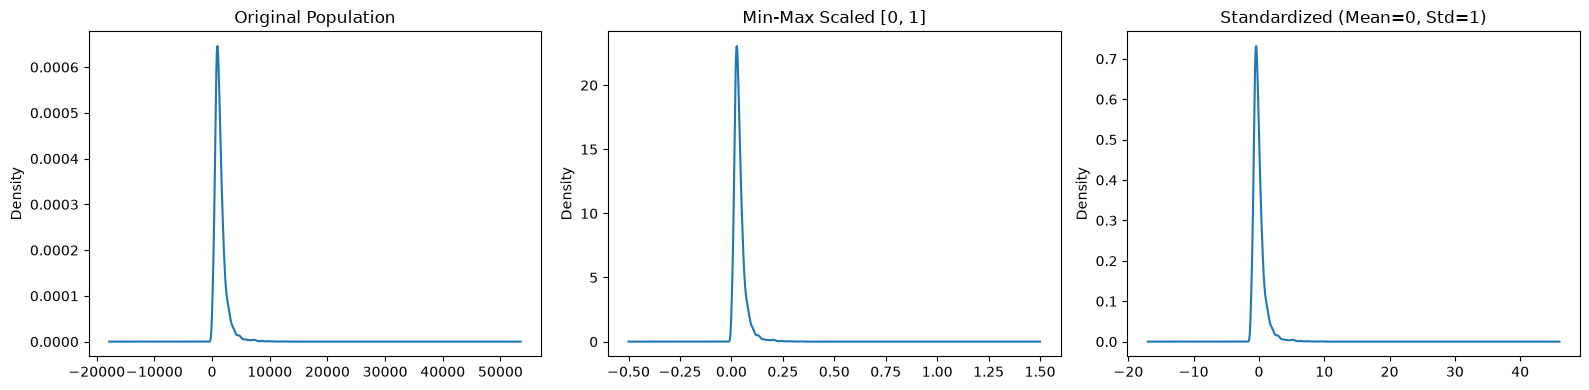

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, StandardScaler

housing = fetch_california_housing(as_frame=True)
df4 = housing.frame[['MedInc', 'HouseAge', 'AveRooms', 'Population']]

# 1. Min-Max Scaling
scaler_minmax = MinMaxScaler()
df4_minmax = pd.DataFrame(scaler_minmax.fit_transform(df4), columns=df4.columns)

# 2. Standardization
scaler_std = StandardScaler()
df4_std = pd.DataFrame(scaler_std.fit_transform(df4), columns=df4.columns)

# 3 & 4. Plot distributions before and after
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df4['Population'].plot(kind='kde', ax=axes[0], title='Original Population')
df4_minmax['Population'].plot(kind='kde', ax=axes[1], title='Min-Max Scaled [0, 1]')
df4_std['Population'].plot(kind='kde', ax=axes[2], title='Standardized (Mean=0, Std=1)')
plt.tight_layout()
plt.show()

In [12]:
# EXPERIMENT 5

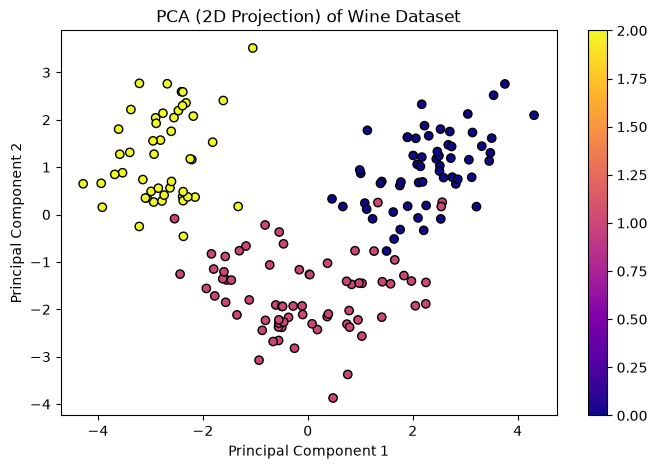

Explained Variance Ratio per PC: [0.36198848 0.1920749 ]
Total Explained Variance by 2 Components: 0.5541


In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load Dataset
wine = load_wine()
X, y = wine.data, wine.target

# 2. Standardize the data
X_std = StandardScaler().fit_transform(X)

# 3 & 4. Apply PCA and reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# 5. Plot the transformed data
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA (2D Projection) of Wine Dataset')
plt.colorbar()
plt.show()

# 6. Calculate explained variance ratio
print("Explained Variance Ratio per PC:", pca.explained_variance_ratio_)
print(f"Total Explained Variance by 2 Components: {sum(pca.explained_variance_ratio_):.4f}")